In [28]:
import pydicom
from pydicom.dataset import Dataset, FileDataset
from pydicom.uid import generate_uid
import os
import matplotlib.pylab as plt
import numpy as np
#import cv2
from skimage import exposure

3
../../Dati_mod/GE_lung/GE_LUNG_4_ASIR40/GE_LUNG_4_ASIR40_3.dcm
(175, 512, 512)
[0.488281, 0.488281]
175


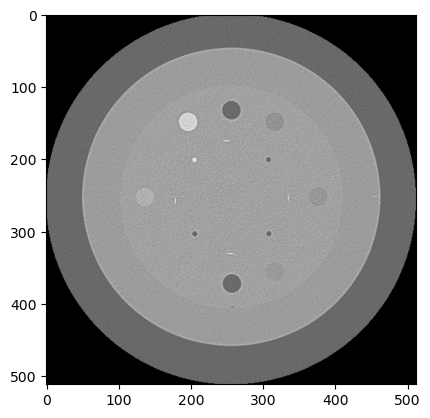

In [ ]:
# Step 1: Load the DICOM image

file_names=[]
directory = '../../GE_LUNG_4_ASIR40'
for filename in os.listdir(directory):
    f = os.path.join(directory, filename)
    if os.path.isfile(f) and filename.endswith('.dcm'):
        file_names.append(f)

print(len(file_names))
print(file_names[0])

dicom_image = pydicom.dcmread(file_names[0])  

# Step 2: Extract relevant image information

slice_selected = 36

pixel_array = dicom_image.pixel_array
print(pixel_array.shape)
pixelarray_slice=pixel_array[slice_selected,:,:]   #FINCHE' LA SLICE THICKNESS è LA STESSA, DOVREBBE RIMANERE UGUALE (-1 rispetto a quella di imagej)

spacing = dicom_image.PixelSpacing
print(spacing)
z_dim = dicom_image.NumberOfFrames
print(z_dim)

plt.imshow(pixelarray_slice, cmap='gray')
plt.show()

In [30]:
# Step 3: Define cylindric ROI parameters

#RICORDA DI INVERTIRE X CON Y
#
#posizioni del GE
center_x = [110, 129, 252, 377, 396, 377, 254, 130]  # Example values for polystyrene, air, LDPE, acrilyc, PMP, Teflon, Delrin
center_y = [257, 328, 400, 329, 258, 185, 115, 185]

#posizioni GE asir 40
#center_x = [132, 148, 252, 356, 372, 356, 253, 149]  # Example values for polystyrene, air, LDPE, acrilyc, PMP, Teflon, Delrin
#center_y = [256, 316, 376, 317, 257, 196, 137, 196]

center_z = slice_selected   #FINCHE' LA SLICE THICKNESS è LA STESSA, DOVREBBE RIMANERE UGUALE
radius = 12   #da verificare
height = 5   #da verificare

#radius = 4
#height = 2

# Step 4: Create a binary mask for all inserts
maschere=[]

for k, j in zip(center_x, center_y):
    print(k)
    print(j)
    mask3D = np.zeros_like(dicom_image.pixel_array).astype('uint16')

    for i in range (mask3D.shape[0]):
        if i >= center_z - height and i <= center_z + height:
            x, y = np.ogrid[:pixelarray_slice.shape[0], :pixelarray_slice.shape[1]]
            mask3D[i,:,:][np.sqrt((x - k)**2 + (y - j)**2) <= radius] = 1
    print(mask3D.shape)
    maschere.append(mask3D)
        
mask3D_pol = maschere[3] 
mask3D_air = maschere[0] 
mask3D_LDPE = maschere[2] 
mask3D_acr = maschere[5] 
mask3D_PMP = maschere[1] 
mask3D_tef = maschere[7]
mask3D_del = maschere[6]
mask3D_water = maschere[4]

132
256
(175, 512, 512)
148
316
(175, 512, 512)
252
376
(175, 512, 512)
356
317
(175, 512, 512)
372
257
(175, 512, 512)
356
196
(175, 512, 512)
253
137
(175, 512, 512)
149
196
(175, 512, 512)


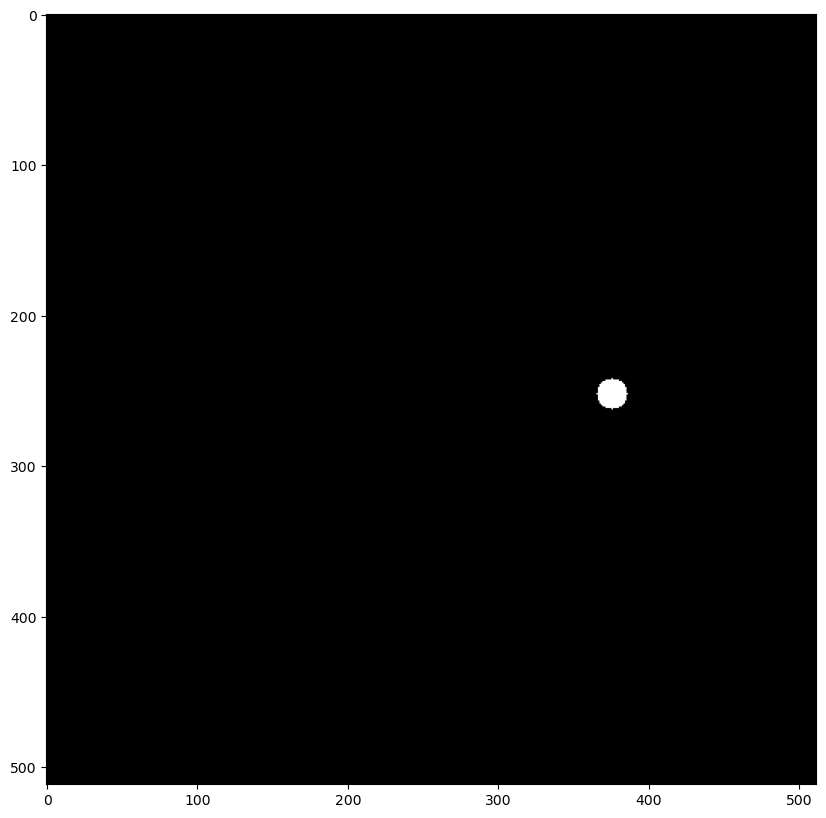

In [31]:
plt.figure(figsize = (10,10))
plt.imshow(mask3D_LDPE[slice_selected,:,:], cmap='gray')

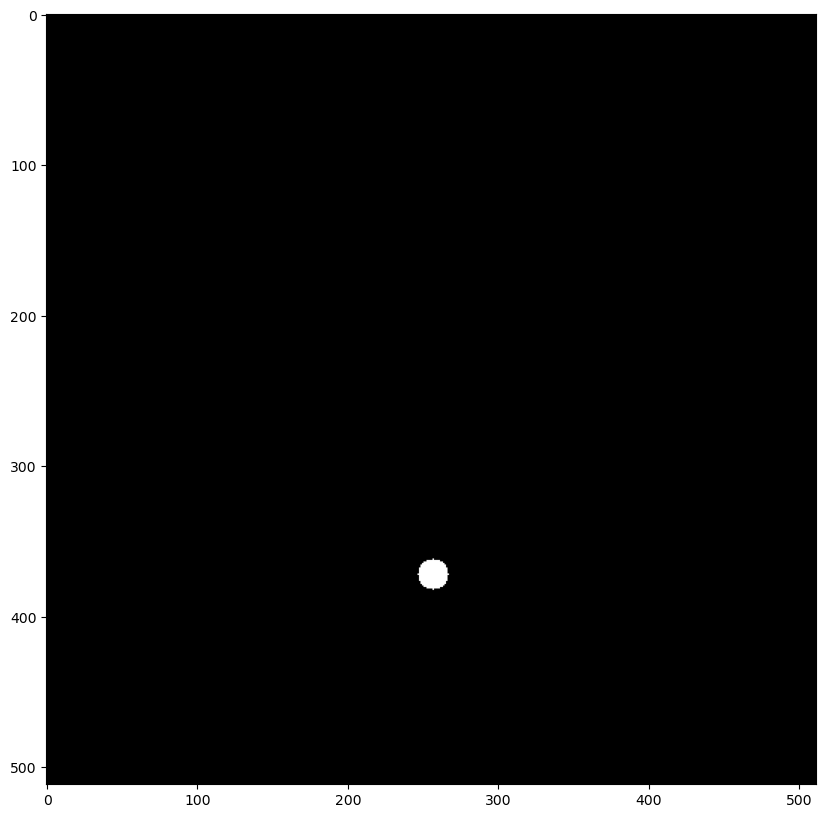

In [32]:
plt.figure(figsize = (10,10))
plt.imshow(mask3D_water[slice_selected,:,:], cmap='gray')



uint16
30768 35714


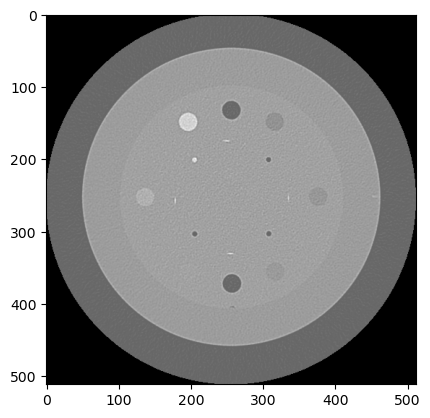

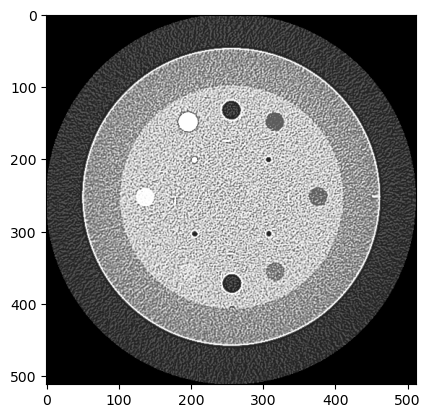

In [33]:

print(pixelarray_slice.dtype)
print(np.min(pixelarray_slice), np.max(pixelarray_slice))

# Setting the medium value to the mean of the image and the windows width to 3 times the standard deviation

display_min = np.mean(pixelarray_slice) - 3*np.std(pixelarray_slice)
display_max = np.mean(pixelarray_slice) + 3*np.std(pixelarray_slice)

# Clip the image values to the display range
dicom_image_clipped = np.clip(pixelarray_slice, display_min, display_max)

plt.imshow(dicom_image_clipped, cmap='gray')
plt.show()

# Normalize the clipped image to the [0, 1] range
dicom_image_normalized = (dicom_image_clipped - display_min) / (display_max - display_min)
dicom_image_equalized = exposure.equalize_hist(dicom_image_normalized)

# Display the normalized image using 'gray' colormap
plt.imshow(dicom_image_equalized, cmap='gray')
plt.show()

<Figure size 640x480 with 0 Axes>

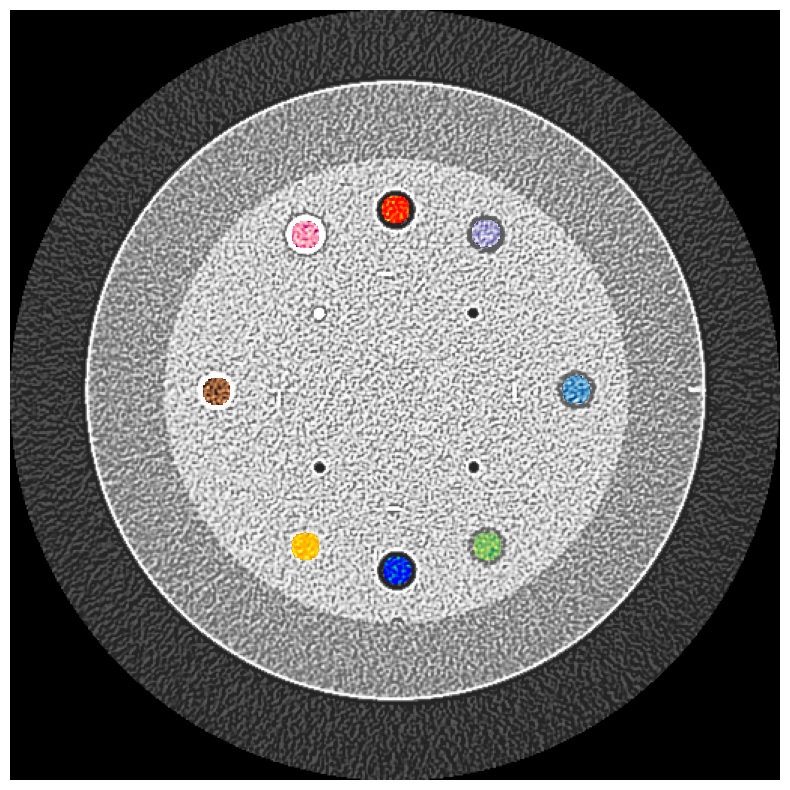

<Figure size 640x480 with 0 Axes>

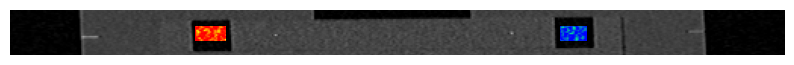

In [34]:
# Specify the slice indices to visualize
slice_indices = [slice_selected]  # Adjust as needed

image_data = pixel_array
mask1_data = mask3D_pol
mask2_data = mask3D_air
mask3_data = mask3D_LDPE
mask4_data = mask3D_acr 
mask5_data = mask3D_PMP  
mask6_data = mask3D_tef 
mask7_data = mask3D_del
mask8_data = mask3D_water


# Iterate over the slice indices
for index in slice_indices:
    # Extract the image and mask slices for the given index
    image_slice = image_data[index]
    mask1_slice = mask1_data[index]
    mask2_slice = mask2_data[index]
    mask3_slice = mask3_data[index]
    mask4_slice = mask4_data[index]
    mask5_slice = mask5_data[index]
    mask6_slice = mask6_data[index]
    mask7_slice = mask7_data[index]
    mask8_slice = mask8_data[index]
    
    # Apply the mask to the image slice
    overlay_slice = np.where(mask1_slice == 1, image_slice, np.nan)  #sostituire 1 al posto di image_slice per avere il colore uniforme nella roi e non la texture
    overlay_slice2 = np.where(mask2_slice == 1, image_slice, np.nan)
    overlay_slice3 = np.where(mask3_slice == 1, image_slice, np.nan)
    overlay_slice4 = np.where(mask4_slice == 1, image_slice, np.nan)
    overlay_slice5 = np.where(mask5_slice == 1, image_slice, np.nan)
    overlay_slice6 = np.where(mask6_slice == 1, image_slice, np.nan)
    overlay_slice7 = np.where(mask7_slice == 1, image_slice, np.nan)
    overlay_slice8 = np.where(mask8_slice == 1, image_slice, np.nan)
    
    # Display the overlay
    plt.clf()
    plt.figure(figsize = (10,10))

    plt.imshow(dicom_image_equalized, cmap='gray')
    plt.imshow(overlay_slice, cmap='summer', alpha=1) #verde_pol
    plt.imshow(overlay_slice2, cmap='autumn',alpha=1)  #rosso_air
    plt.imshow(overlay_slice3, cmap='Blues', alpha=1)  #blu_LDPE
    plt.imshow(overlay_slice4, cmap='Wistia', alpha=1)  #giallo_acr
    plt.imshow(overlay_slice5, cmap='Purples', alpha=1)  #viola_PMP
    plt.imshow(overlay_slice6, cmap='RdPu', alpha=1)    #fucsia_tef
    plt.imshow(overlay_slice7, cmap='copper', alpha=1)   #marrone_del
    plt.imshow(overlay_slice8, cmap='winter', alpha=1)   #blu_water

    plt.axis('off')
    plt.show()


slice_indices_y = [256]  # Adjust as needed
# Iterate over the slice indices
for index in slice_indices_y:
    # Extract the image and mask slices for the given index
    image_slice = image_data[:,:,index]
    mask1_slice = mask1_data[:,:,index]
    mask2_slice = mask2_data[:,:,index]
    mask3_slice = mask3_data[:,:,index]
    mask4_slice = mask4_data[:,:,index]
    mask5_slice = mask5_data[:,:,index]
    mask6_slice = mask6_data[:,:,index]
    mask7_slice = mask7_data[:,:,index]
    mask8_slice = mask8_data[:,:,index]
    
    # Apply the mask to the image slice
    overlay_slice = np.where(mask1_slice == 1, image_slice, np.nan)  #sostituire 1 al posto di image_slice per avere il colore uniforme nella roi e non la texture
    overlay_slice2 = np.where(mask2_slice == 1, image_slice, np.nan)
    overlay_slice3 = np.where(mask3_slice == 1, image_slice, np.nan)
    overlay_slice4 = np.where(mask4_slice == 1, image_slice, np.nan)
    overlay_slice5 = np.where(mask5_slice == 1, image_slice, np.nan)
    overlay_slice6 = np.where(mask6_slice == 1, image_slice, np.nan)
    overlay_slice7 = np.where(mask7_slice == 1, image_slice, np.nan)
    overlay_slice8 = np.where(mask8_slice == 1, image_slice, np.nan)
    
    # Display the overlay
    plt.clf()
    plt.figure(figsize = (10,10))

    plt.imshow(image_slice, cmap='gray')
    plt.imshow(overlay_slice, cmap='summer', alpha=1) #verde_pol
    plt.imshow(overlay_slice2, cmap='autumn',alpha=1)  #rosso_air
    plt.imshow(overlay_slice3, cmap='Blues', alpha=1)  #blu_LDPE
    plt.imshow(overlay_slice4, cmap='Wistia', alpha=1)  #giallo_acr
    plt.imshow(overlay_slice5, cmap='Purples', alpha=1)  #viola_PMP
    plt.imshow(overlay_slice6, cmap='RdPu', alpha=1)    #fucsia_tef
    plt.imshow(overlay_slice7, cmap='copper', alpha=1)   #marrone_del
    plt.imshow(overlay_slice8, cmap='winter', alpha=1)   #blu_water
    plt.ylim(50,20)
    plt.axis('off')
    plt.show()

In [35]:
def create_dicom_from_array(mask, output_path, path):
    # Create a new DICOM dataset
    ds = FileDataset(output_path, {}, file_meta=dicom_image.file_meta, preamble=b'\0' * 128)
    ds.SOPClassUID = '1.2.840.10008.5.1.4.1.1.66' # DICOM SEG   #'1.2.840.10008.5.1.4.1.1.2'  # CT Image Storage
    ds.SOPInstanceUID = generate_uid()
    ds.file_meta = pydicom.Dataset()
    ds.FrameOfReferenceUID = dicom_image.FrameOfReferenceUID  
    ds.ImagePositionPatient = dicom_image.ImagePositionPatient
    ds.ImageOrientationPatient = dicom_image.ImageOrientationPatient

    # Set necessary metadata
    ds.PatientName = 'Anonymous'
    ds.PatientID = dicom_image.PatientID
    ds.Rows = mask.shape[1]
    ds.Columns = mask.shape[2]
    ds.PixelSpacing = dicom_image.PixelSpacing  # Define pixel spacing
    ds.SliceThickness = dicom_image.SliceThickness  # Define slice thickness
    ds.NumberOfFrames = mask.shape[0]
    ds.SamplesPerPixel = dicom_image.SamplesPerPixel # Set Samples Per Pixel
    ds.PhotometricInterpretation = 'MONOCHROME2'  # Set Photometric Interpretation
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 1  # Unsigned integer
    if hasattr(dicom_image, 'RotationDirection'):
        ds.RotationDirection = dicom_image.RotationDirection
    ds.PositionReferenceIndicator = dicom_image.PositionReferenceIndicator
    if hasattr(dicom_image, 'SliceLocation'):
        ds.SliceLocation = dicom_image.SliceLocation
    if hasattr(dicom_image, 'PatientPosition'):
        ds.PatientPosition = dicom_image.PatientPosition

    # Set pixel data
    ds.PixelData = mask.tobytes()
    
    ds.file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian
    # Save the DICOM file
    ds.save_as(path+output_path)

In [36]:
# Example usage
maschere = [mask3D_pol, mask3D_air, mask3D_LDPE, mask3D_acr, mask3D_PMP, mask3D_tef, mask3D_del, mask3D_water] # Example 3D array
output_path = ['mask_pol.dcm', 'mask_air.dcm', 'mask_LDPE.dcm', 'mask_acr.dcm', 'mask_PMP.dcm', 'mask_tef.dcm', 'mask_del.dcm', 'mask_water.dcm']
path = '../../Dati_mod/GE_lung/GE_LUNG4_Asir40_1_mask/'  # Output path for the DICOM file

for mask_name, output in zip (maschere, output_path):
    
    create_dicom_from_array(mask_name, output, path)

#Open and display the mask_pol.dcm file
mask_pol = pydicom.dcmread(path+'mask_pol.dcm')
mask_pol_slice = mask_pol.pixel_array[35,:,:]
plt.imshow(mask_pol_slice, cmap='gray')
plt.show()
